#### 16- I denna uppgift ska du göra ett komplett ML-flöde där du modellerar diamantpriser som finns tillgängliga i datasetet “diamonds.csv”

In [27]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt


In [28]:
diamonds = pd.read_csv('diamonds.csv')
diamonds

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [29]:
diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 4.5 MB


### 53940 observationer -- inga saknade värden -- Datayper (float64(6) - int64(2) - string(3))
    - Categoriska : cut, color, clarity.
    - Numeriska: carat, depth, table, price, x, y, z
    - Onödiga: Unnamed.
    - Target: price.

In [30]:
diamonds.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [31]:
x = diamonds.drop(columns=['price', 'Unnamed: 0'])
y = diamonds['price']

x_train_val, x_test, y_train_val, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.15, random_state=42)

In [32]:
categorical_features = ['cut', 'color', 'clarity']
categorical_features

['cut', 'color', 'clarity']

In [33]:
numerical_features = [
    column for column in x.columns if column not in categorical_features
]
numerical_features

['carat', 'depth', 'table', 'x', 'y', 'z']

In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numerical_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

print(f'Träningsdata: {x_train.shape}')
print(f'Testdata: {x_test.shape}')

Träningsdata: (36679, 9)
Testdata: (10788, 9)


In [35]:
models = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=None,
    ),
}

results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model),
    ])
    pipeline.fit(x_train, y_train)
    predictions = pipeline.predict(x_val)

    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_val, predictions),
        'RMSE': mean_squared_error(y_val, predictions) ** 0.5,
        'R2': r2_score(y_val, predictions),
    })
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

,Model,MAE,RMSE,R2
1,Random Forest,273.023496,560.933953,0.98000
0,Ridge,739.025447,1101.913831,0.92282


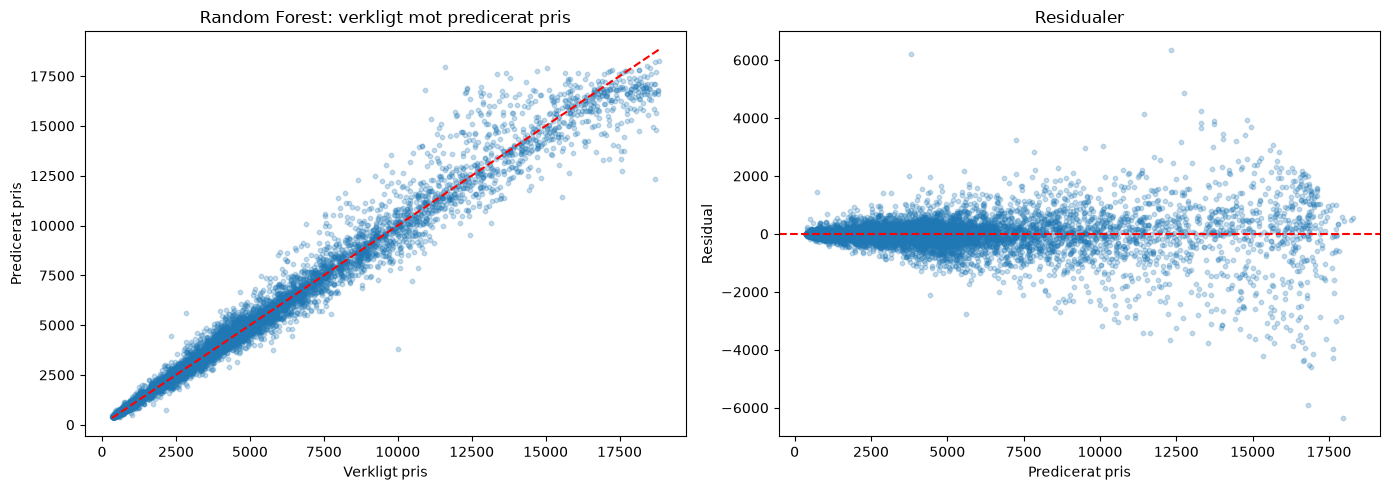

Bästa modell: Random Forest
MAE: 270.16
RMSE: 550.57
R2: 0.9809


In [36]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
train_chosen = best_model.fit(x_train_val,y_train_val)
test_predictions = best_model.predict(x_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, test_predictions, alpha=0.25, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title(f'{best_model_name}: verkligt mot predicerat pris')
axes[0].set_xlabel('Verkligt pris')
axes[0].set_ylabel('Predicerat pris')

residuals = y_test - test_predictions
axes[1].scatter(test_predictions, residuals, alpha=0.25, s=10)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residualer')
axes[1].set_xlabel('Predicerat pris')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

print(f'Bästa modell: {best_model_name}')
print(f'MAE: {mean_absolute_error(y_test, test_predictions):.2f}')
print(f'RMSE: {mean_squared_error(y_test, test_predictions) ** 0.5:.2f}')
print(f'R2: {r2_score(y_test, test_predictions):.4f}')

In [37]:
# Feature importance för den bästa modellen
if best_model_name == 'Random Forest':
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
    importances = best_model.named_steps['model'].feature_importances_
    importance_df = (
        pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        .sort_values('Importance', ascending=False)
        .head(15)
    )
    display(importance_df)

# Exempel på en ny diamant att predicera
new_diamond = pd.DataFrame({
    'carat': [1.0],
    'cut': ['Ideal'],
    'color': ['G'],
    'clarity': ['VS2'],
    'depth': [61.5],
    'table': [55.0],
    'x': [6.4],
    'y': [6.4],
    'z': [3.9],
})

predicted_price = best_model.predict(new_diamond)[0]
print(f'Predicerat pris för den nya diamanten: {predicted_price:.0f}')

,Feature,Importance
0,numeric__carat,0.613422
4,numeric__y,0.272781
21,categorical__clarity_SI2,0.019434
18,categorical__clarity_I1,0.014999
20,categorical__clarity_SI1,0.014462
17,categorical__color_J,0.010312
16,categorical__color_I,0.007273
23,categorical__clarity_VS2,0.007092
15,categorical__color_H,0.005649
22,categorical__clarity_VS1,0.005627


Predicerat pris för den nya diamanten: 6405
